# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [7]:
# Paso 1 — Selección y descarga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from itertools import combinations
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

# Mis 3 activos asignados (distintos a los usados en clase)
activos = ["CVX", "JNJ", "PG"]

datos = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

print("Dimensiones:", datos.shape)
print("Período:", datos.index.min().date(), "a", datos.index.max().date())
datos.head()   # primeras 5 filas

[*********************100%***********************]  3 of 3 completed

Dimensiones: (502, 15)
Período: 2024-01-02 a 2025-12-31


Price            Close                                High              \
Ticker             CVX         JNJ          PG         CVX         JNJ   
Date                                                                     
2024-01-02  133.236771  148.073685  138.312866  135.019441  149.619492   
2024-01-03  135.777023  148.999344  137.475922  136.543572  149.434393   
2024-01-04  134.288544  148.684601  138.229126  137.577572  149.934198   
2024-01-05  134.056778  149.147430  137.085342  135.509658  149.341806   
2024-01-08  133.254547  149.517700  138.266342  133.432811  149.638037   

Price                          Low                                Open  \
Ticker              PG         CVX         JNJ          PG         CVX   
Date                                                                     
2024-01-02  138.935895  133.022859  145.130161  136.053209  133.691360   
2024-01-03  138.740582  132.523643  147.916354  136.862186  133.156497   
2024-01-04  138.805672  134.226144  148.490211  137.410827  136.962549   
2024-01-05  138.433690  133.548724  147.610874  136.276337  135.465089   
2024-01-08  138.480214  130.651851  147.740484  137.299242  132.291904   

Price                                 Volume                    
Ticker             JNJ          PG       CVX      JNJ       PG  
Date                                                            
2024-01-02  145.259749  136.099707   8879700  9622100  7238400  
2024-01-03  148.693883  137.940870  10255300  8232000  7697500  
2024-01-04  149.573202  137.671197   8220300  6766600  7067400  
2024-01-05  148.564276  138.294211   7455400  5602500  5294200  
2024-01-08  149.119684  137.541024  10038200  6569800  8255300

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

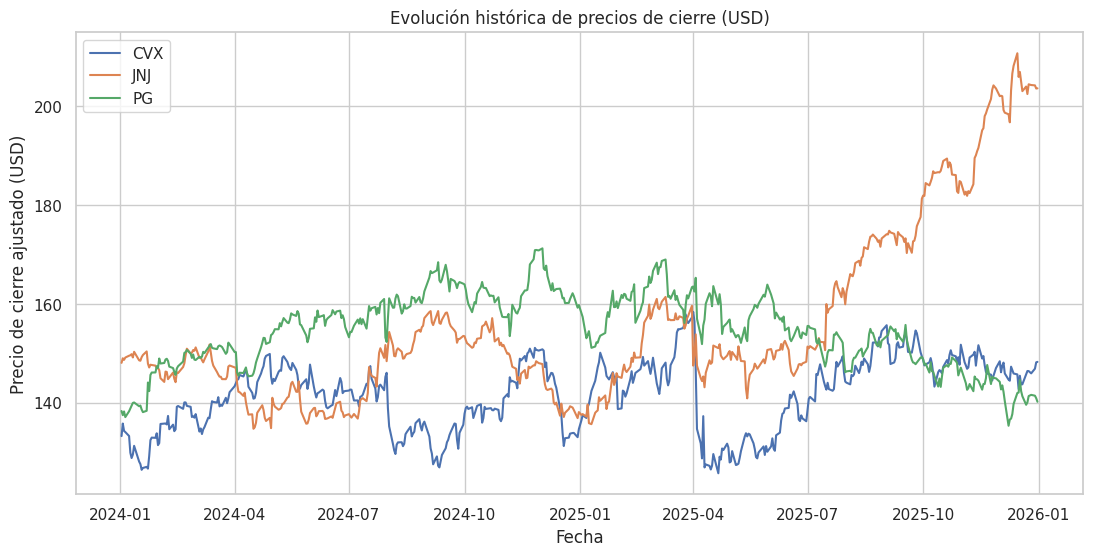

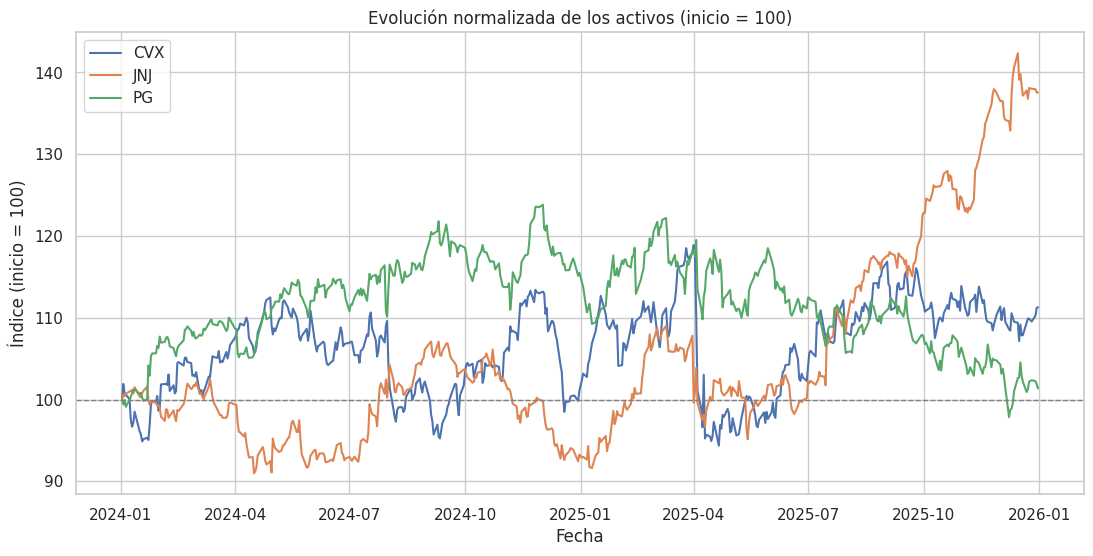

In [8]:
# 1. Extraer los precios de cierre
cierre = datos["Close"][activos]

# 2. Graficar precios originales
fig, ax = plt.subplots(figsize=(13, 6))
for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)
ax.set_title("Evolución histórica de precios de cierre (USD)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre ajustado (USD)")
ax.legend()
plt.show()

# 3. Normalizar y graficar en base 100
cierre_norm = cierre / cierre.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 6))
for activo in activos:
    ax.plot(cierre_norm.index, cierre_norm[activo], label=activo)
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title("Evolución normalizada de los activos (inicio = 100)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()
plt.show()

In [17]:
# Interpretación
pmin, pmax = cierre.min(), cierre.max()
var = cierre_norm.iloc[-1] - 100                       # variación acumulada (%)
mejor, peor = var.idxmax(), var.idxmin()
orden_precio = list(cierre.iloc[-1].sort_values(ascending=False).index)
orden_var = list(var.sort_values(ascending=False).index)
rangos = "; ".join(f"{a} se movió entre {pmin[a]:.0f} y {pmax[a]:.0f} USD" for a in activos)

if orden_precio == orden_var:
    nota_orden = (f"El orden final por precio coincide con el orden por variación acumulada ({' > '.join(orden_var)})")
else:
    nota_orden = (f"El orden final por precio ({' > '.join(orden_precio)}) no coincide con el orden por crecimiento relativo "
                  f"({' > '.join(orden_var)}): leer solo el gráfico de precios habría llevado a una conclusión distinta sobre cuál rindió más.")

display(Markdown(f"""
**Interpretación** En el gráfico de precios originales las series están en **escalas distintas** ({rangos}). La altura de cada línea refleja cuántos dólares vale la acción, no cuánto rindió: la línea más alta parece "mejor" aunque no haya crecido más, y los movimientos de los activos baratos se ven aplastados. En el gráfico normalizado todas parten de 100, así que la comparación pasa a ser el **cambio relativo respecto al propio punto de partida**: {mejor} terminó en {cierre_norm[mejor].iloc[-1]:.1f} ({var[mejor]:+.1f} %) y {peor} en {cierre_norm[peor].iloc[-1]:.1f} ({var[peor]:+.1f} %). {nota_orden}

Por eso el gráfico normalizado es **metodológicamente más correcto** para comparar rendimiento histórico: elimina el efecto del nivel nominal del precio, pone a todos los activos en la misma unidad (índice) y permite leer directamente el rendimiento acumulado de cada uno. Sigue siendo una lectura histórica del período, no una recomendación de inversión.
"""))


**Interpretación** En el gráfico de precios originales las series están en **escalas distintas** (CVX se movió entre 126 y 158 USD; JNJ se movió entre 135 y 211 USD; PG se movió entre 135 y 171 USD). La altura de cada línea refleja cuántos dólares vale la acción, no cuánto rindió: la línea más alta parece "mejor" aunque no haya crecido más, y los movimientos de los activos baratos se ven aplastados. En el gráfico normalizado todas parten de 100, así que la comparación pasa a ser el **cambio relativo respecto al propio punto de partida**: JNJ terminó en 137.5 (+37.5 %) y PG en 101.4 (+1.4 %). El orden final por precio coincide con el orden por variación acumulada (JNJ > CVX > PG)

Por eso el gráfico normalizado es **metodológicamente más correcto** para comparar rendimiento histórico: elimina el efecto del nivel nominal del precio, pone a todos los activos en la misma unidad (índice) y permite leer directamente el rendimiento acumulado de cada uno. Sigue siendo una lectura histórica del período, no una recomendación de inversión.


## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Ticker,CVX,JNJ,PG
Date,,,
2024-01-03,0.019066,0.006251,-0.006051
2024-01-04,-0.010963,-0.002112,0.005479
2024-01-05,-0.001726,0.003113,-0.008275
2024-01-08,-0.005984,0.002483,0.008615
2024-01-09,-0.025418,0.000619,0.004103


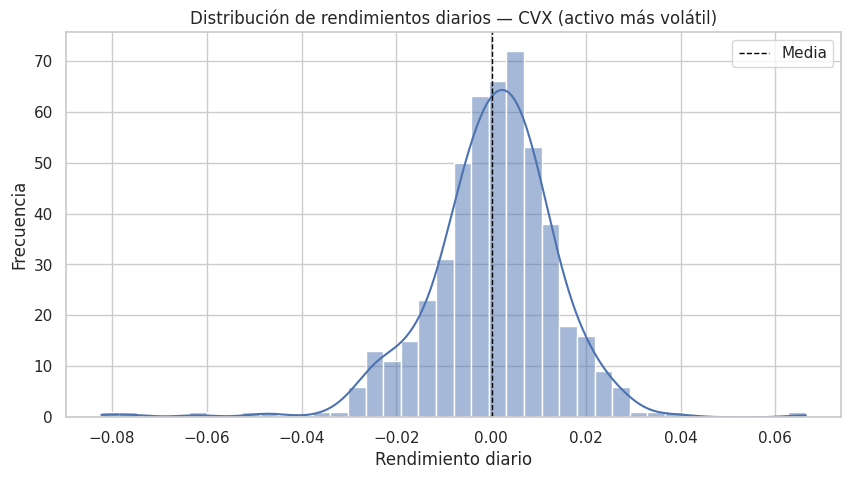

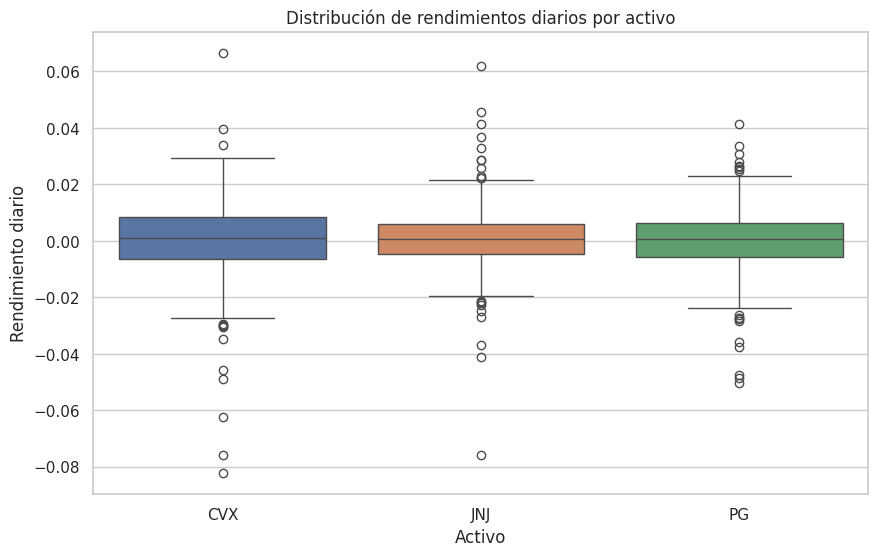

In [10]:
# 1. Calcular rendimientos diarios y eliminar NaN
rend = cierre.pct_change().dropna()
display(rend.head())

# 2. Histograma del activo más volátil (mayor desviación estándar)
mas_volatil = rend.std().idxmax()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=rend, x=mas_volatil, bins=40, kde=True, ax=ax)
ax.axvline(rend[mas_volatil].mean(), linestyle="--", linewidth=1, color="black", label="Media")
ax.set_title(f"Distribución de rendimientos diarios — {mas_volatil} (activo más volátil)")
ax.set_xlabel("Rendimiento diario")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()

# 3. Boxplot comparativo de rendimientos
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rend, ax=ax)
ax.set_title("Distribución de rendimientos diarios por activo")
ax.set_xlabel("Activo")
ax.set_ylabel("Rendimiento diario")
plt.show()

In [18]:
# Interpretación

# --- Dispersión ---
std = rend.std()
q1, q3 = rend.quantile(0.25), rend.quantile(0.75)
iqr = q3 - q1
mas_disp, menos_disp = std.idxmax(), std.idxmin()

# --- Valores atípicos (regla 1.5 x IQR, la misma que usa el boxplot) ---
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_out = (rend < lim_inf) | (rend > lim_sup)
n_out = mask_out.sum()

# --- Contexto: fechas de resultados trimestrales (si yfinance las entrega) ---
def fechas_reaccion(ticker):
    """Fechas de publicación de resultados y el día siguiente (por si salen después del cierre)."""
    try:
        ed = yf.Ticker(ticker).get_earnings_dates(limit=28)
        f = pd.to_datetime(ed.index)
        f = (f.tz_convert(None) if f.tz is not None else f).normalize()
        return set(f) | set(f + pd.Timedelta(days=1))
    except Exception:
        return None

resultados = {a: fechas_reaccion(a) for a in activos}
hay_resultados = all(v is not None for v in resultados.values())

# --- Shocks de mercado verificados (aranceles, abril de 2025) ---
shocks = {
    "2025-04-03": "caída del mercado tras el anuncio de aranceles recíprocos (2-abr)",
    "2025-04-04": "segunda jornada de caída por aranceles",
    "2025-04-09": "rally por la pausa de 90 días de aranceles",
}

filas = []
for a in activos:
    for fecha, v in rend[a][mask_out[a]].items():
        ctx = []
        if resultados[a] is not None and fecha.normalize() in resultados[a]:
            ctx.append("resultados trimestrales")
        if str(fecha.date()) in shocks:
            ctx.append("shock de mercado: " + shocks[str(fecha.date())])
        filas.append({"activo": a, "fecha": fecha.date(), "rendimiento_%": round(v * 100, 2),
                      "contexto": " + ".join(ctx) if ctx else "sin evento identificado (verificar noticias)"})
outliers = pd.DataFrame(filas, columns=["activo", "fecha", "rendimiento_%", "contexto"])
outliers = outliers.sort_values("rendimiento_%", key=abs, ascending=False).reset_index(drop=True)

print("Valores atípicos por activo:", n_out.astype(int).to_dict())
display(outliers.head(15))

n_total = len(outliers)
n_res = int(outliers["contexto"].str.contains("resultados").sum())
n_shock = int(outliers["contexto"].str.contains("shock").sum())
n_sin = int(outliers["contexto"].str.startswith("sin evento").sum())
curt = rend[mas_disp].kurt()
forma = ("colas más pesadas que las de una distribución normal (los eventos extremos ocurren más de lo que sugeriría una normal)"
         if curt > 1 else "colas relativamente cercanas a las de una distribución normal")
nota_res = ("" if hay_resultados else " Nota: no se pudieron consultar las fechas de resultados desde yfinance, así que esa comparación no está incluida.")
resto = (f"las {n_sin} restantes no tienen un evento identificado por el código y conviene contrastarlas con las noticias de cada compañía en esas fechas"
         if n_sin > 0 else "todas tienen un evento asociado identificado por el código")

display(Markdown(f"""
**Interpretación**

- **Dispersión y riesgo.** {mas_disp} presenta la mayor dispersión: desviación estándar diaria de {std[mas_disp]*100:.2f} % y una caja (rango intercuartílico) de {iqr[mas_disp]*100:.2f} puntos; {menos_disp} presenta la menor ({std[menos_disp]*100:.2f} % y {iqr[menos_disp]*100:.2f} puntos). Una dispersión mayor significa que sus rendimientos diarios se alejan más del promedio, es decir, más **volatilidad histórica** y, en ese sentido, **más riesgo**: el rango de resultados diarios posibles es más amplio. El histograma de {mas_disp} muestra además {forma} (curtosis en exceso = {curt:.2f}).
- **Valores atípicos.** El boxplot marca {n_total} observaciones fuera de los bigotes ({', '.join(f'{a}: {int(n_out[a])}' for a in activos)}). No son errores de datos: son jornadas en que el precio reaccionó de forma inusual a un evento, ya sea de la compañía (como la publicación de resultados trimestrales) o de todo el mercado. De esas {n_total}, {n_res} coinciden con publicación de resultados y {n_shock} con shocks de mercado verificados (3, 4 y 9 de abril de 2025, por los aranceles); {resto}.{nota_res}
"""))

Valores atípicos por activo: {'CVX': 13, 'JNJ': 20, 'PG': 18}


,activo,fecha,rendimiento_%,contexto
0,CVX,2025-04-04,-8.22,shock de mercado: segunda jornada de caída por...
1,JNJ,2025-04-01,-7.59,sin evento identificado (verificar noticias)
2,CVX,2025-04-10,-7.57,sin evento identificado (verificar noticias)
3,CVX,2025-04-09,6.65,shock de mercado: rally por la pausa de 90 día...
4,CVX,2025-04-03,-6.22,shock de mercado: caída del mercado tras el an...
5,JNJ,2025-07-16,6.19,resultados trimestrales
6,PG,2025-04-04,-5.01,shock de mercado: segunda jornada de caída por...
7,CVX,2024-08-01,-4.89,sin evento identificado (verificar noticias)
8,PG,2024-07-30,-4.84,resultados trimestrales
9,PG,2025-02-14,-4.75,sin evento identificado (verificar noticias)



**Interpretación**

- **Dispersión y riesgo.** CVX presenta la mayor dispersión: desviación estándar diaria de 1.38 % y una caja (rango intercuartílico) de 1.49 puntos; PG presenta la menor (1.07 % y 1.21 puntos). Una dispersión mayor significa que sus rendimientos diarios se alejan más del promedio, es decir, más **volatilidad histórica** y, en ese sentido, **más riesgo**: el rango de resultados diarios posibles es más amplio. El histograma de CVX muestra además colas más pesadas que las de una distribución normal (los eventos extremos ocurren más de lo que sugeriría una normal) (curtosis en exceso = 5.72).
- **Valores atípicos.** El boxplot marca 51 observaciones fuera de los bigotes (CVX: 13, JNJ: 20, PG: 18). No son errores de datos: son jornadas en que el precio reaccionó de forma inusual a un evento, ya sea de la compañía (como la publicación de resultados trimestrales) o de todo el mercado. De esas 51, 7 coinciden con publicación de resultados y 7 con shocks de mercado verificados (3, 4 y 9 de abril de 2025, por los aranceles); las 37 restantes no tienen un evento identificado por el código y conviene contrastarlas con las noticias de cada compañía en esas fechas.


## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Ticker,CVX,JNJ,PG
Ticker,,,
CVX,1.000,0.162,0.096
JNJ,0.162,1.000,0.387
PG,0.096,0.387,1.000


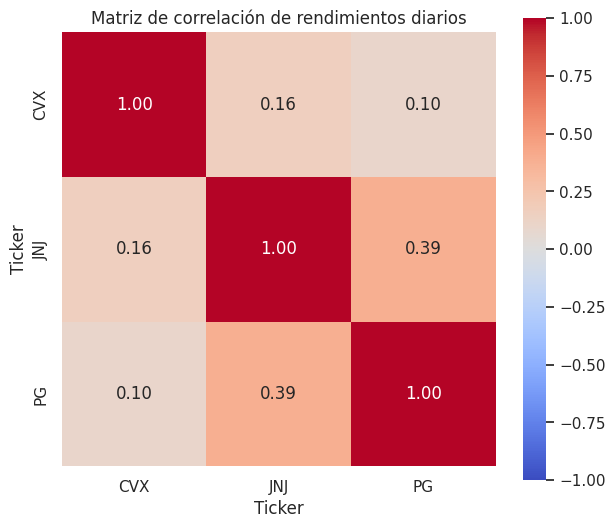

In [12]:
# 1. Calcular matriz de correlación de Pearson
corr = rend.corr(method="pearson")
display(corr.round(3))

# 2. Heatmap con Seaborn
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matriz de correlación de rendimientos diarios")
plt.show()

In [19]:
# Interpretación
pares = pd.Series({(a, b): corr.loc[a, b] for a, b in combinations(corr.columns, 2)}).sort_values()
par_alto, r_alto = pares.index[-1], pares.iloc[-1]
par_bajo, r_bajo = pares.index[0], pares.iloc[0]

# Riesgo conjunto de cada par con pesos iguales (50 % / 50 %), medido como desviación estándar diaria
riesgo_par = pd.Series({(a, b): rend[[a, b]].mean(axis=1).std() for a, b in combinations(corr.columns, 2)}).sort_values()
par_div, r_div = riesgo_par.index[0], riesgo_par.iloc[0]
print("Riesgo conjunto (desv. estándar diaria, %) de cada par con pesos 50/50:")
print((riesgo_par * 100).round(3))

if max(abs(r_alto), abs(r_bajo)) >= 0.7:
    fuerte = f"Sí: el par {par_alto[0]}–{par_alto[1]} tiene una correlación fuerte ({r_alto:.2f})." if abs(r_alto) >= 0.7 else f"Sí: el par {par_bajo[0]}–{par_bajo[1]} tiene una correlación fuerte ({r_bajo:.2f})."
else:
    fuerte = (f"No hay correlaciones fuertes (cercanas a 1 o -1): van de {r_bajo:.2f} ({par_bajo[0]}–{par_bajo[1]}) "
              f"a {r_alto:.2f} ({par_alto[0]}–{par_alto[1]}), que se leen como débiles o moderadas.")

if par_div == par_bajo:
    elegido = (f"{par_div[0]} y {par_div[1]}: es a la vez el par menos correlacionado ({r_bajo:.2f}) y el de menor riesgo conjunto "
               f"({r_div*100:.2f} % diario con pesos iguales).")
else:
    elegido = (f"{par_div[0]} y {par_div[1]}: tiene el menor riesgo conjunto con pesos iguales ({r_div*100:.2f} % diario), "
               f"aunque el par menos correlacionado es {par_bajo[0]}–{par_bajo[1]} ({r_bajo:.2f}); el riesgo conjunto depende tanto de la "
               "correlación como de la volatilidad de cada activo, y aquí pesó más la volatilidad.")

display(Markdown(f"""
**Interpretación**

- **¿Correlación fuerte?** {fuerte} La correlación solo mide relación **lineal** entre los rendimientos diarios del período y no implica causalidad.
- **Portafolio diversificado.** Para minimizar el riesgo conjunto elegiría **{elegido}** Cuando dos activos no se mueven igual, las caídas de uno se compensan en parte con el otro y la variabilidad del conjunto baja. Es un resultado histórico del período 2024-2026 y no garantiza que la relación se mantenga.
"""))

Riesgo conjunto (desv. estándar diaria, %) de cada par con pesos 50/50:
JNJ  PG     0.906
CVX  PG     0.914
     JNJ    0.949
dtype: float64



**Interpretación**

- **¿Correlación fuerte?** No hay correlaciones fuertes (cercanas a 1 o -1): van de 0.10 (CVX–PG) a 0.39 (JNJ–PG), que se leen como débiles o moderadas. La correlación solo mide relación **lineal** entre los rendimientos diarios del período y no implica causalidad.
- **Portafolio diversificado.** Para minimizar el riesgo conjunto elegiría **JNJ y PG: tiene el menor riesgo conjunto con pesos iguales (0.91 % diario), aunque el par menos correlacionado es CVX–PG (0.10); el riesgo conjunto depende tanto de la correlación como de la volatilidad de cada activo, y aquí pesó más la volatilidad.** Cuando dos activos no se mueven igual, las caídas de uno se compensan en parte con el otro y la variabilidad del conjunto baja. Es un resultado histórico del período 2024-2026 y no garantiza que la relación se mantenga.


## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [20]:
# Resumen de estadísticas descriptivas de los rendimientos diarios
resumen = pd.DataFrame({
    "Media": rend.mean(),
    "Mediana": rend.median(),
    "Desviación estándar": rend.std(),
    "Mínimo": rend.min(),
    "Máximo": rend.max(),
})
display(resumen)

print("\nMismos valores en % (más fáciles de leer):")
display((resumen * 100).round(3))

# Conclusión para un inversionista ficticio (redactada con los números de mis datos)
mejor_media = resumen["Media"].idxmax()
peor_dia = rend.min().idxmin()
mejor_dia = rend.max().idxmax()
fecha_peor = rend[peor_dia].idxmin().date()
fecha_mejor = rend[mejor_dia].idxmax().date()
ordenado = resumen["Desviación estándar"].sort_values()
estable, volatil = ordenado.index[0], ordenado.index[-1]

display(Markdown(f"""
### Conclusión
De acuerdo con los datos diarios entre enero de 2024 y enero de 2026, esto es lo que muestran los estadísticos de **{', '.join(activos)}**:

- **Rendimiento típico:** {mejor_media} tuvo la media diaria más alta ({resumen.loc[mejor_media, 'Media']*100:.3f} %). Las medias diarias son pequeñas por naturaleza; lo relevante es compararlas con el riesgo. La mediana de {mejor_media} fue {resumen.loc[mejor_media, 'Mediana']*100:.3f} %.
- **Riesgo:** {volatil} fue el más volátil (desviación estándar diaria de {resumen.loc[volatil, 'Desviación estándar']*100:.2f} %) y {estable} el más estable ({resumen.loc[estable, 'Desviación estándar']*100:.2f} %).
- **Extremos:** la peor jornada fue de {resumen.loc[peor_dia, 'Mínimo']*100:.2f} % ({peor_dia}, {fecha_peor}) y la mejor de {resumen.loc[mejor_dia, 'Máximo']*100:+.2f} % ({mejor_dia}, {fecha_mejor}); un inversionista debe estar preparado para días así.
- **Diversificación:** según el análisis de correlación, la combinación de menor riesgo conjunto fue {par_div[0]} y {par_div[1]}.
- **Advertencia:** estos estadísticos describen el pasado y no garantizan el comportamiento futuro. Este análisis es un ejercicio académico y no constituye asesoría financiera.
"""))

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
CVX,0.000309,0.001183,0.013784,-0.082244,0.066457
JNJ,0.000697,0.000819,0.011006,-0.075916,0.061932
PG,0.000085,0.000651,0.010742,-0.050119,0.041390



Mismos valores en % (más fáciles de leer):


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
CVX,0.031,0.118,1.378,-8.224,6.646
JNJ,0.070,0.082,1.101,-7.592,6.193
PG,0.008,0.065,1.074,-5.012,4.139



### Conclusión 
De acuerdo con los datos diarios entre enero de 2024 y enero de 2026, esto es lo que muestran los estadísticos de **CVX, JNJ, PG**:

- **Rendimiento típico:** JNJ tuvo la media diaria más alta (0.070 %). Las medias diarias son pequeñas por naturaleza; lo relevante es compararlas con el riesgo. La mediana de JNJ fue 0.082 %.
- **Riesgo:** CVX fue el más volátil (desviación estándar diaria de 1.38 %) y PG el más estable (1.07 %).
- **Extremos:** la peor jornada fue de -8.22 % (CVX, 2025-04-04) y la mejor de +6.65 % (CVX, 2025-04-09); un inversionista debe estar preparado para días así.
- **Diversificación:** según el análisis de correlación, la combinación de menor riesgo conjunto fue JNJ y PG.
- **Advertencia:** estos estadísticos describen el pasado y no garantizan el comportamiento futuro. Este análisis es un ejercicio académico y no constituye asesoría financiera.
